In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [2]:
!ls ../data/processed/

data_clean.csv


In [3]:
FILE = '../data/processed/data_clean.csv'

df = pd.read_csv(FILE)

print(df.shape)
df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,NaN,DSL,0.000,1.000,0.000,0.000,0.000,0.000,Month-to-month,1,Electronic check,29.850,29.850,0
1,Male,0,0,0,34,1,0.000,DSL,1.000,0.000,1.000,0.000,0.000,0.000,One year,0,Mailed check,56.950,1889.500,0
2,Male,0,0,0,2,1,0.000,DSL,1.000,1.000,0.000,0.000,0.000,0.000,Month-to-month,1,Mailed check,53.850,108.150,1
3,Male,0,0,0,45,0,NaN,DSL,1.000,0.000,1.000,1.000,0.000,0.000,One year,0,Bank transfer (automatic),42.300,1840.750,0
4,Female,0,0,0,2,1,0.000,Fiber optic,0.000,0.000,0.000,0.000,0.000,0.000,Month-to-month,1,Electronic check,70.700,151.650,1


# ETL

In [ ]:
bin_cols = [
    'Churn', 'SeniorCitizen',
    'Partner', 'Dependents', 'PhoneService',
    'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaperlessBilling'
]

categorical_cols = df.select_dtypes(include='str').columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns
numerical_cols = [col for col in numerical_cols if col not in bin_cols]

In [5]:
print(numerical_cols)
print(categorical_cols)
print(bin_cols)

assert len(categorical_cols) + len(numerical_cols) + len(bin_cols) == df.shape[1]

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
['gender', 'InternetService', 'Contract', 'PaymentMethod']
['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']


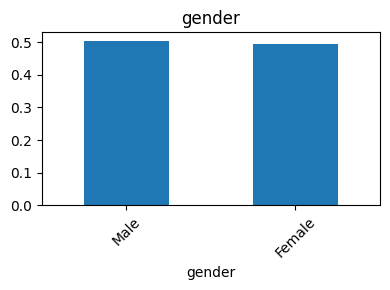

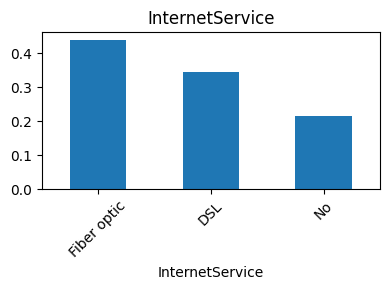

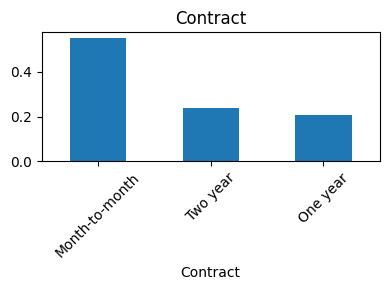

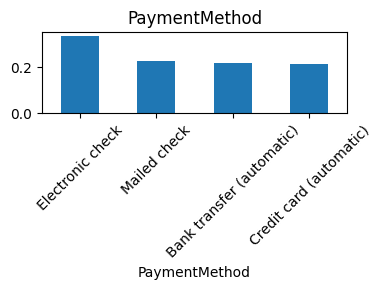

In [6]:
for col in categorical_cols:
    counts = df[col].value_counts(dropna=False, normalize=True)
    plt.figure(figsize=(4, 3))
    counts.plot(kind='bar')
    plt.title(f"{col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [7]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750
TotalCharges,7043.000,2279.734,2266.794,0.000,398.550,1394.550,3786.600,8684.800


In [8]:
df[bin_cols].mean()

Churn              0.265
Partner            0.483
Dependents         0.300
PhoneService       0.903
MultipleLines      0.467
OnlineSecurity     0.366
OnlineBackup       0.440
DeviceProtection   0.439
TechSupport        0.370
StreamingTV        0.491
StreamingMovies    0.495
PaperlessBilling   0.592
dtype: float64

# EDA